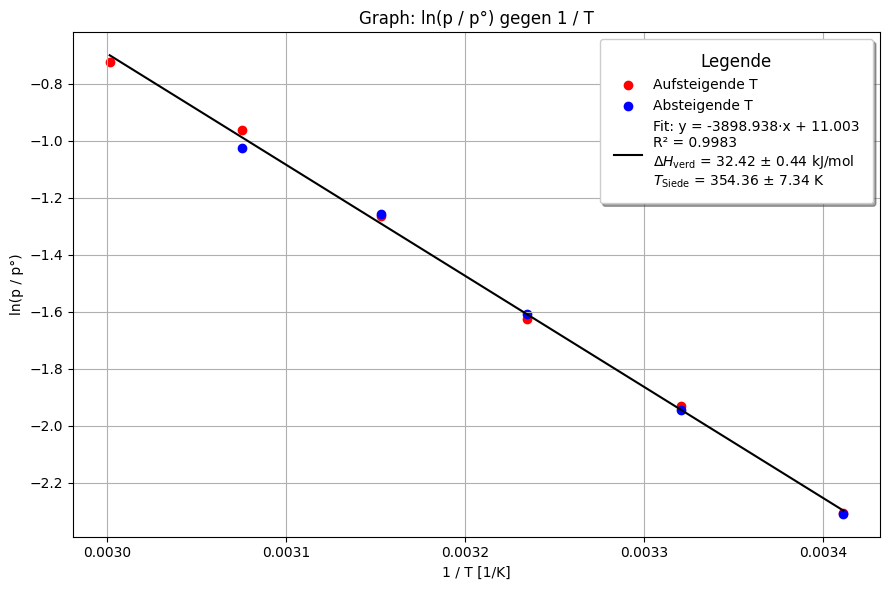

ΔH_verd = 32415.77 ± 442.34 J/mol
        = 32.42 ± 0.44 kJ/mol
T_siede = 354.36 ± 7.34 K


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Gegebene Daten
T = np.array([293.15, 301.15, 309.15, 317.15, 325.15, 333.15,
              325.15, 317.15, 309.15, 301.15, 293.15])
p = np.array([101.0, 146.8, 199.6, 286.2, 386.7, 491.1, 363.5, 287.8, 203.0, 144.8, 100.7])

# Konstanten
p0 = 1013.25  # mbar
R = 8.314     # J/(mol·K)

# Linearisierte Größen
inv_T = 1 / T
ln_p = np.log(p_korr / p0)

# Trennung: aufsteigend und absteigend
inv_T_up = inv_T[:6]
ln_p_up = ln_p[:6]
inv_T_down = inv_T[6:]
ln_p_down = ln_p[6:]

# Lineare Regression
slope, intercept, r_value, p_value, std_err = linregress(inv_T, ln_p)
r_squared = r_value**2

# Zielgrößen
delta_H_v = -slope * R  # J/mol
T_siede = -slope / intercept  # K
delta_H_v_err = R * std_err

# Fehler Achsenabschnitt (intercept)
n = len(inv_T)
residuals = ln_p - (slope * inv_T + intercept)
s_yx = np.sqrt(np.sum(residuals**2) / (n - 2))
s_xx = np.sum((inv_T - np.mean(inv_T))**2)
intercept_err = s_yx * np.sqrt(1/n + (np.mean(inv_T)**2) / s_xx)

# KORRIGIERTE Gaußsche Fehlerfortpflanzung:
T_siede_err = T_siede * np.sqrt((std_err / slope)**2 + (intercept_err / intercept)**2)

# Fitlinie
x_fit = np.linspace(inv_T.min(), inv_T.max(), 300)
y_fit = slope * x_fit + intercept

# Fit-Info als String für Legende
fit_info = (
    f"Fit: y = {slope:.3f}·x + {intercept:.3f}\n"
    f"R² = {r_squared:.4f}\n"
    f"$\\Delta H_{{\\mathrm{{verd}}}}$ = {delta_H_v/1000:.2f} ± {delta_H_v_err/1000:.2f} kJ/mol\n"
    f"$T_{{\\mathrm{{Siede}}}}$ = {T_siede:.2f} ± {T_siede_err:.2f} K"
)

# Plot
plt.figure(figsize=(9, 6))
plt.scatter(inv_T_up, ln_p_up, color='red', label='Aufsteigende T')
plt.scatter(inv_T_down, ln_p_down, color='blue', label='Absteigende T')
plt.plot(x_fit, y_fit, color='black', label=fit_info)

plt.xlabel('1 / T [1/K]')
plt.ylabel('ln(p / p°)')
plt.title('Graph: ln(p / p°) gegen 1 / T')
plt.grid(True)
plt.legend(loc='upper right', fontsize=10, frameon=True, shadow=True, borderpad=1, ncol=1,
           title='Legende', title_fontsize=12)
plt.tight_layout()
plt.show()

# Ergebnisse ausgeben
print(f"ΔH_verd = {delta_H_v:.2f} ± {delta_H_v_err:.2f} J/mol")
print(f"        = {delta_H_v/1000:.2f} ± {delta_H_v_err/1000:.2f} kJ/mol")
print(f"T_siede = {T_siede:.2f} ± {T_siede_err:.2f} K")

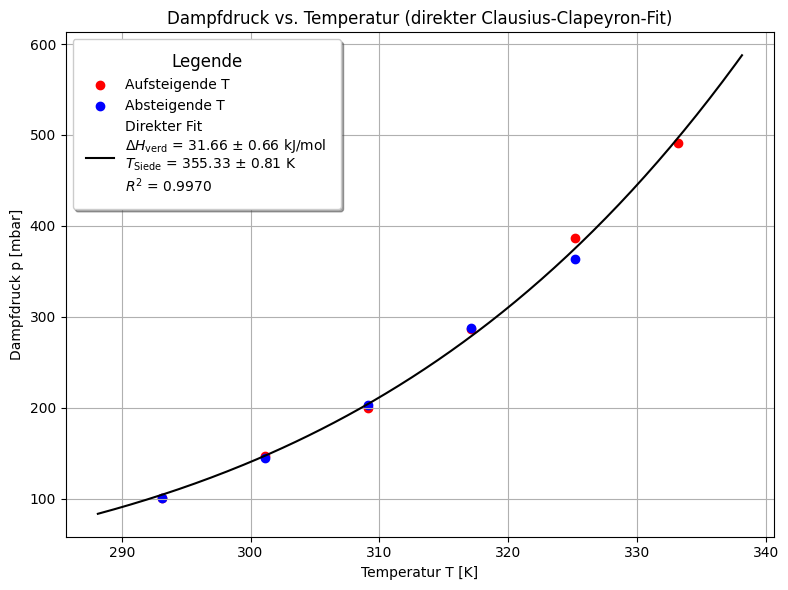


Formel: p(T) = p0 * exp[ (ΔH_v / R) * (1/T_siede - 1/T) ]
ΔH_verd = 31663.63 ± 656.02 J/mol
T_Siede = 355.33 ± 0.81 K
R² = 0.9970


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Messdaten
T = np.array([293.15, 301.15, 309.15, 317.15, 325.15, 333.15, 325.15, 317.15, 309.15, 301.15, 293.15])
p = np.array([101.0, 146.8, 199.6, 286.2, 386.7, 491.1, 363.5, 287.8, 203.0, 144.8, 100.7])

# Konstanten
p0 = 1013  # mbar
R = 8.314462618  # J/mol·K

# Define the function based on the provided formula
def fit_function(T, H, T_SD):
  return 1013 * np.exp(H / 8.314 * (1/T_SD - 1/T))


# Nichtlinearer Fit
initial_guess = [40000, 373.15]
params, cov = curve_fit(pressure_model, T, p, p0=initial_guess)
delta_H_v, T_siede = params
delta_H_v_err, T_siede_err = np.sqrt(np.diag(cov))

# R² berechnen
residuals = p - pressure_model(T, *params)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((p - np.mean(p))**2)
r_squared = 1 - (ss_res / ss_tot)

# Fit-Kurve
T_fit = np.linspace(min(T) - 5, max(T) + 5, 200)
p_fit = pressure_model(T_fit, *params)

# Aufspalten der Messpunkte in auf- und absteigende Temperatur
T_up = T[:6]
p_up = p[:6]
T_down = T[6:]
p_down = p[6:]

# Fit-Label mit Formelparametern und R²
fit_label = (
    f'Direkter Fit\n'
    r'$\Delta H_\mathrm{{verd}}$'
    f' = {delta_H_v/1000:.2f} ± {delta_H_v_err/1000:.2f} kJ/mol\n'
    r'$T_\mathrm{{Siede}}$'
    f' = {T_siede:.2f} ± {T_siede_err:.2f} K\n'
    r'$R^2$'
    f' = {r_squared:.4f}'
)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(T_up, p_up, color='red', label='Aufsteigende T')
plt.scatter(T_down, p_down, color='blue', label='Absteigende T')
plt.plot(T_fit, p_fit, color='black', label=fit_label)

plt.xlabel('Temperatur T [K]')
plt.ylabel('Dampfdruck p [mbar]')
plt.title('Dampfdruck vs. Temperatur (direkter Clausius-Clapeyron-Fit)')
plt.legend(loc='upper left', fontsize=10, frameon=True, shadow=True, borderpad=1, ncol=1,
   title='Legende', title_fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# Fit-Ergebnisse auch in Konsole ausgeben
print(f"\nFormel: p(T) = p0 * exp[ (ΔH_v / R) * (1/T_siede - 1/T) ]")
print(f"ΔH_verd = {delta_H_v:.2f} ± {delta_H_v_err:.2f} J/mol")
print(f"T_Siede = {T_siede:.2f} ± {T_siede_err:.2f} K")
print(f"R² = {r_squared:.4f}")